In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

In [3]:
df=pd.read_csv("/Users/arifekbalrashid/sih2026/ml/synthetic_saathi_training_v1.csv")

In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 10000
Number of columns: 19


In [5]:
df.head()

,personnel_id,assessment_date,week_number,unit_id,duty_hours,night_shifts,consecutive_duty_days,rest_hours,deployment_days,leave_gap_days,sleep_quality,workload_score,recovery_score,average_duty_hours_4w,workload_change_pct,recovery_change_pct,previous_risk_score,risk_score,risk_level
0,P1000,2025-02-17,1,U002,58.90,0,11,8.40,36,22,3.00,4.00,3.00,58.90,NaN,NaN,NaN,23.80,Low
1,P1000,2025-02-24,2,U002,71.70,1,4,6.30,10,30,2.00,3.00,NaN,65.30,21.80,NaN,23.80,28.40,Low
2,P1000,2025-03-03,3,U002,56.20,3,11,2.50,88,37,2.00,4.00,2.00,62.30,-21.60,NaN,28.40,29.30,Low
3,P1000,2025-03-10,4,U002,71.70,4,18,7.30,31,44,2.00,4.00,2.00,64.60,27.60,0.00,29.30,31.70,Moderate
4,P1000,2025-03-17,5,U002,72.70,4,9,4.30,70,52,3.00,2.00,1.00,68.10,1.30,-50.00,31.70,48.70,Moderate


In [6]:
df.tail()

,personnel_id,assessment_date,week_number,unit_id,duty_hours,night_shifts,consecutive_duty_days,rest_hours,deployment_days,leave_gap_days,sleep_quality,workload_score,recovery_score,average_duty_hours_4w,workload_change_pct,recovery_change_pct,previous_risk_score,risk_score,risk_level
9995,P1749,2025-06-16,14,U003,50.70,4,6,8.50,1,196,2.00,4.00,4.00,57.40,-19.50,0.00,52.00,57.50,Elevated
9996,P1749,2025-06-23,15,U003,47.50,2,4,8.20,17,203,3.00,4.00,5.00,54.80,-6.20,25.00,57.50,53.30,Elevated
9997,P1749,2025-06-30,16,U003,39.90,5,4,8.40,14,208,3.00,3.00,4.00,50.30,-15.90,-20.00,53.30,49.50,Moderate
9998,P1749,2025-07-07,17,U003,67.20,1,10,9.10,98,217,4.00,4.00,4.00,51.30,68.30,0.00,49.50,54.90,Elevated
9999,P1749,2025-07-14,18,U003,50.90,0,5,10.20,6,225,4.00,2.00,5.00,51.40,-24.20,25.00,54.90,52.70,Elevated


In [7]:
df.columns.tolist()

['personnel_id',
 'assessment_date',
 'week_number',
 'unit_id',
 'duty_hours',
 'night_shifts',
 'consecutive_duty_days',
 'rest_hours',
 'deployment_days',
 'leave_gap_days',
 'sleep_quality',
 'workload_score',
 'recovery_score',
 'average_duty_hours_4w',
 'workload_change_pct',
 'recovery_change_pct',
 'previous_risk_score',
 'risk_score',
 'risk_level']

In [8]:
df.dtypes

personnel_id              object
assessment_date           object
week_number                int64
unit_id                   object
duty_hours               float64
night_shifts               int64
consecutive_duty_days      int64
rest_hours               float64
deployment_days            int64
leave_gap_days             int64
sleep_quality            float64
workload_score           float64
recovery_score           float64
average_duty_hours_4w    float64
workload_change_pct      float64
recovery_change_pct      float64
previous_risk_score      float64
risk_score               float64
risk_level                object
dtype: object

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   personnel_id           10000 non-null  object 
 1   assessment_date        10000 non-null  object 
 2   week_number            10000 non-null  int64  
 3   unit_id                10000 non-null  object 
 4   duty_hours             10000 non-null  float64
 5   night_shifts           10000 non-null  int64  
 6   consecutive_duty_days  10000 non-null  int64  
 7   rest_hours             10000 non-null  float64
 8   deployment_days        10000 non-null  int64  
 9   leave_gap_days         10000 non-null  int64  
 10  sleep_quality          9640 non-null   float64
 11  workload_score         9753 non-null   float64
 12  recovery_score         9575 non-null   float64
 13  average_duty_hours_4w  10000 non-null  float64
 14  workload_change_pct    9250 non-null   float64
 15  rec

In [10]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": (missing / len(df)) * 100
})

missing_df = missing_df.sort_values(
    "Missing Count",
    ascending=False
)

missing_df

,Missing Count,Missing %
recovery_change_pct,1532,15.32
previous_risk_score,750,7.50
workload_change_pct,750,7.50
recovery_score,425,4.25
sleep_quality,360,3.60
workload_score,247,2.47
personnel_id,0,0.00
risk_score,0,0.00
average_duty_hours_4w,0,0.00
leave_gap_days,0,0.00


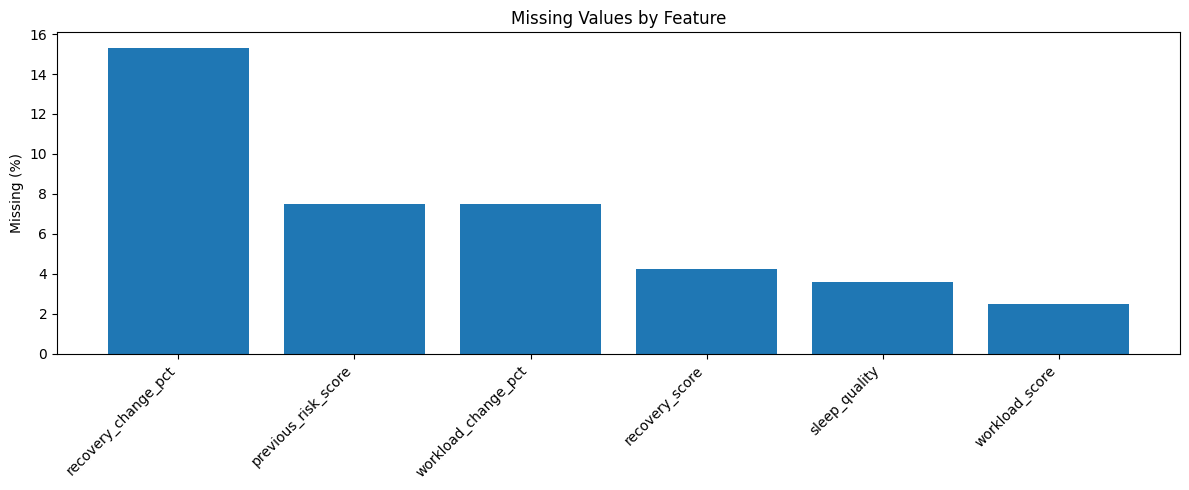

In [11]:
plt.figure(figsize=(12, 5))

missing_percent = (
    df.isnull()
    .mean()
    .sort_values(ascending=False) * 100
)

missing_percent = missing_percent[
    missing_percent > 0
]

if len(missing_percent) > 0:
    plt.bar(
        missing_percent.index,
        missing_percent.values
    )

    plt.ylabel("Missing (%)")
    plt.title("Missing Values by Feature")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

else:
    print("No missing values found.")

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.duplicated(
        subset=["personnel_id", "assessment_date"]
    ).sum()

np.int64(0)

In [14]:
unique_personnel = df["personnel_id"].nunique()
unique_personnel


750

In [15]:
observations_per_person = (
    df.groupby("personnel_id")
      .size()
)

observations_per_person.describe()

count   750.00
mean     13.33
std       2.67
min       9.00
25%      11.00
50%      13.00
75%      16.00
max      19.00
dtype: float64

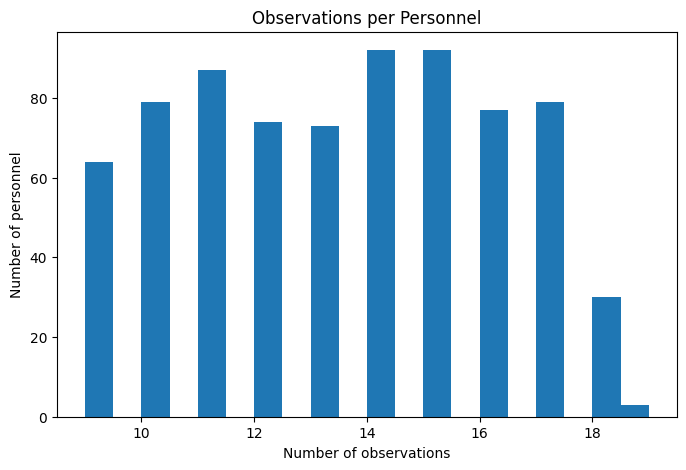

In [16]:
plt.figure(figsize=(8, 5))

plt.hist(
    observations_per_person,
    bins=20
)

plt.xlabel("Number of observations")
plt.ylabel("Number of personnel")
plt.title("Observations per Personnel")

plt.show()

In [17]:
df["assessment_date"] = pd.to_datetime(
    df["assessment_date"]
)

print(
    "Start date:",
    df["assessment_date"].min()
)

print(
    "End date:",
    df["assessment_date"].max()
)

Start date: 2025-01-06 00:00:00
End date: 2025-07-21 00:00:00


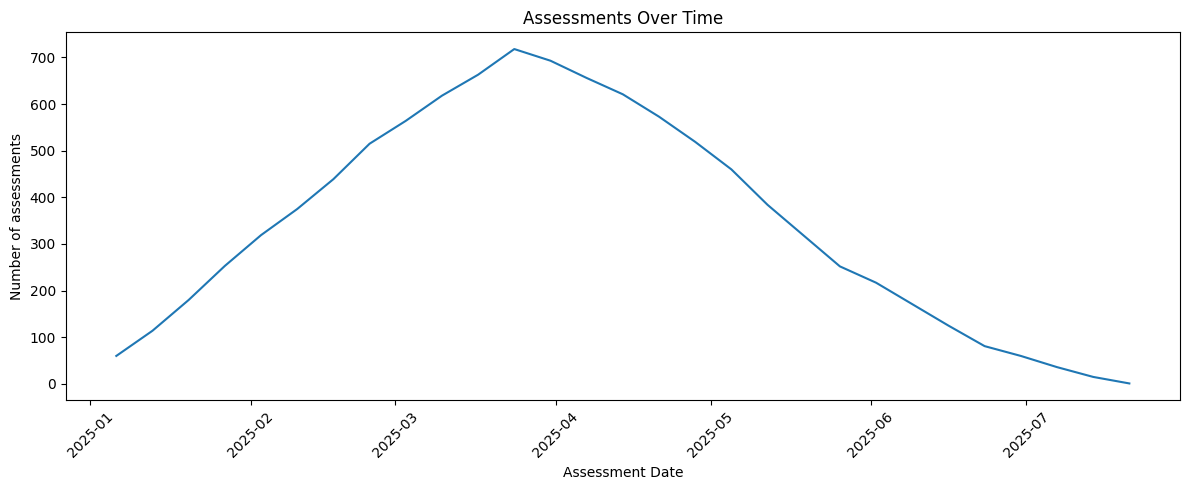

In [18]:
observations_by_date = (
    df.groupby("assessment_date")
      .size()
)

plt.figure(figsize=(12, 5))

plt.plot(
    observations_by_date.index,
    observations_by_date.values
)

plt.xlabel("Assessment Date")
plt.ylabel("Number of assessments")
plt.title("Assessments Over Time")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [19]:
print(
    "Minimum week:",
    df["week_number"].min()
)

print(
    "Maximum week:",
    df["week_number"].max()
)

Minimum week: 1
Maximum week: 19


In [20]:
df["week_number"].value_counts().sort_index().head(20)

week_number
1     750
2     750
3     750
4     750
5     750
6     750
7     750
8     750
9     750
10    686
11    607
12    520
13    446
14    373
15    281
16    189
17    112
18     33
19      3
Name: count, dtype: int64

In [21]:
print(
    "Number of units:",
    df["unit_id"].nunique()
)

print(
    df["unit_id"].value_counts()
)

Number of units: 15
unit_id
U012    847
U002    802
U003    800
U008    755
U007    751
U005    729
U013    700
U015    665
U009    648
U011    637
U014    614
U010    610
U004    512
U001    492
U006    438
Name: count, dtype: int64


In [22]:
FEATURES = [
    "duty_hours",
    "night_shifts",
    "consecutive_duty_days",
    "rest_hours",
    "deployment_days",
    "leave_gap_days",
    "sleep_quality",
    "workload_score",
    "recovery_score",
    "average_duty_hours_4w",
    "workload_change_pct",
    "recovery_change_pct",
    "previous_risk_score"
]

TARGET = "risk_score"

df[FEATURES + [TARGET]].describe().T

,count,mean,std,min,25%,50%,75%,max
duty_hours,10000.00,54.49,14.58,0.80,44.60,54.60,64.40,120.00
night_shifts,10000.00,2.03,1.49,0.00,1.00,2.00,3.00,7.00
consecutive_duty_days,10000.00,7.18,5.18,0.00,3.00,7.00,11.00,27.00
rest_hours,10000.00,8.50,1.91,0.60,7.20,8.50,9.80,17.00
deployment_days,10000.00,41.09,43.02,0.00,12.00,28.00,56.00,365.00
leave_gap_days,10000.00,110.62,45.02,6.00,78.00,111.00,143.00,253.00
sleep_quality,9640.00,3.01,1.06,1.00,2.00,3.00,4.00,5.00
workload_score,9753.00,3.01,1.15,1.00,2.00,3.00,4.00,5.00
recovery_score,9575.00,2.97,1.23,1.00,2.00,3.00,4.00,5.00
average_duty_hours_4w,10000.00,54.61,11.50,15.30,46.80,54.50,62.40,94.50


In [23]:
ranges = {
    "duty_hours": (0, 120),
    "night_shifts": (0, 7),
    "consecutive_duty_days": (0, 60),
    "rest_hours": (0, 24),
    "deployment_days": (0, 365),
    "leave_gap_days": (0, 730),
    "sleep_quality": (1, 5),
    "workload_score": (1, 5),
    "recovery_score": (1, 5),
    "average_duty_hours_4w": (0, 120),
    "workload_change_pct": (-100, 200),
    "recovery_change_pct": (-100, 100),
    "previous_risk_score": (0, 100),
    "risk_score": (0, 100)
}

range_results = []

for column, (minimum, maximum) in ranges.items():

    invalid = (
        (df[column] < minimum) |
        (df[column] > maximum)
    ).sum()

    range_results.append({
        "Feature": column,
        "Expected Min": minimum,
        "Expected Max": maximum,
        "Actual Min": df[column].min(),
        "Actual Max": df[column].max(),
        "Invalid Values": invalid
    })

range_check = pd.DataFrame(range_results)

range_check

,Feature,Expected Min,Expected Max,Actual Min,Actual Max,Invalid Values
0,duty_hours,0,120,0.80,120.00,0
1,night_shifts,0,7,0.00,7.00,0
2,consecutive_duty_days,0,60,0.00,27.00,0
3,rest_hours,0,24,0.60,17.00,0
4,deployment_days,0,365,0.00,365.00,0
5,leave_gap_days,0,730,6.00,253.00,0
6,sleep_quality,1,5,1.00,5.00,0
7,workload_score,1,5,1.00,5.00,0
8,recovery_score,1,5,1.00,5.00,0
9,average_duty_hours_4w,0,120,15.30,94.50,0


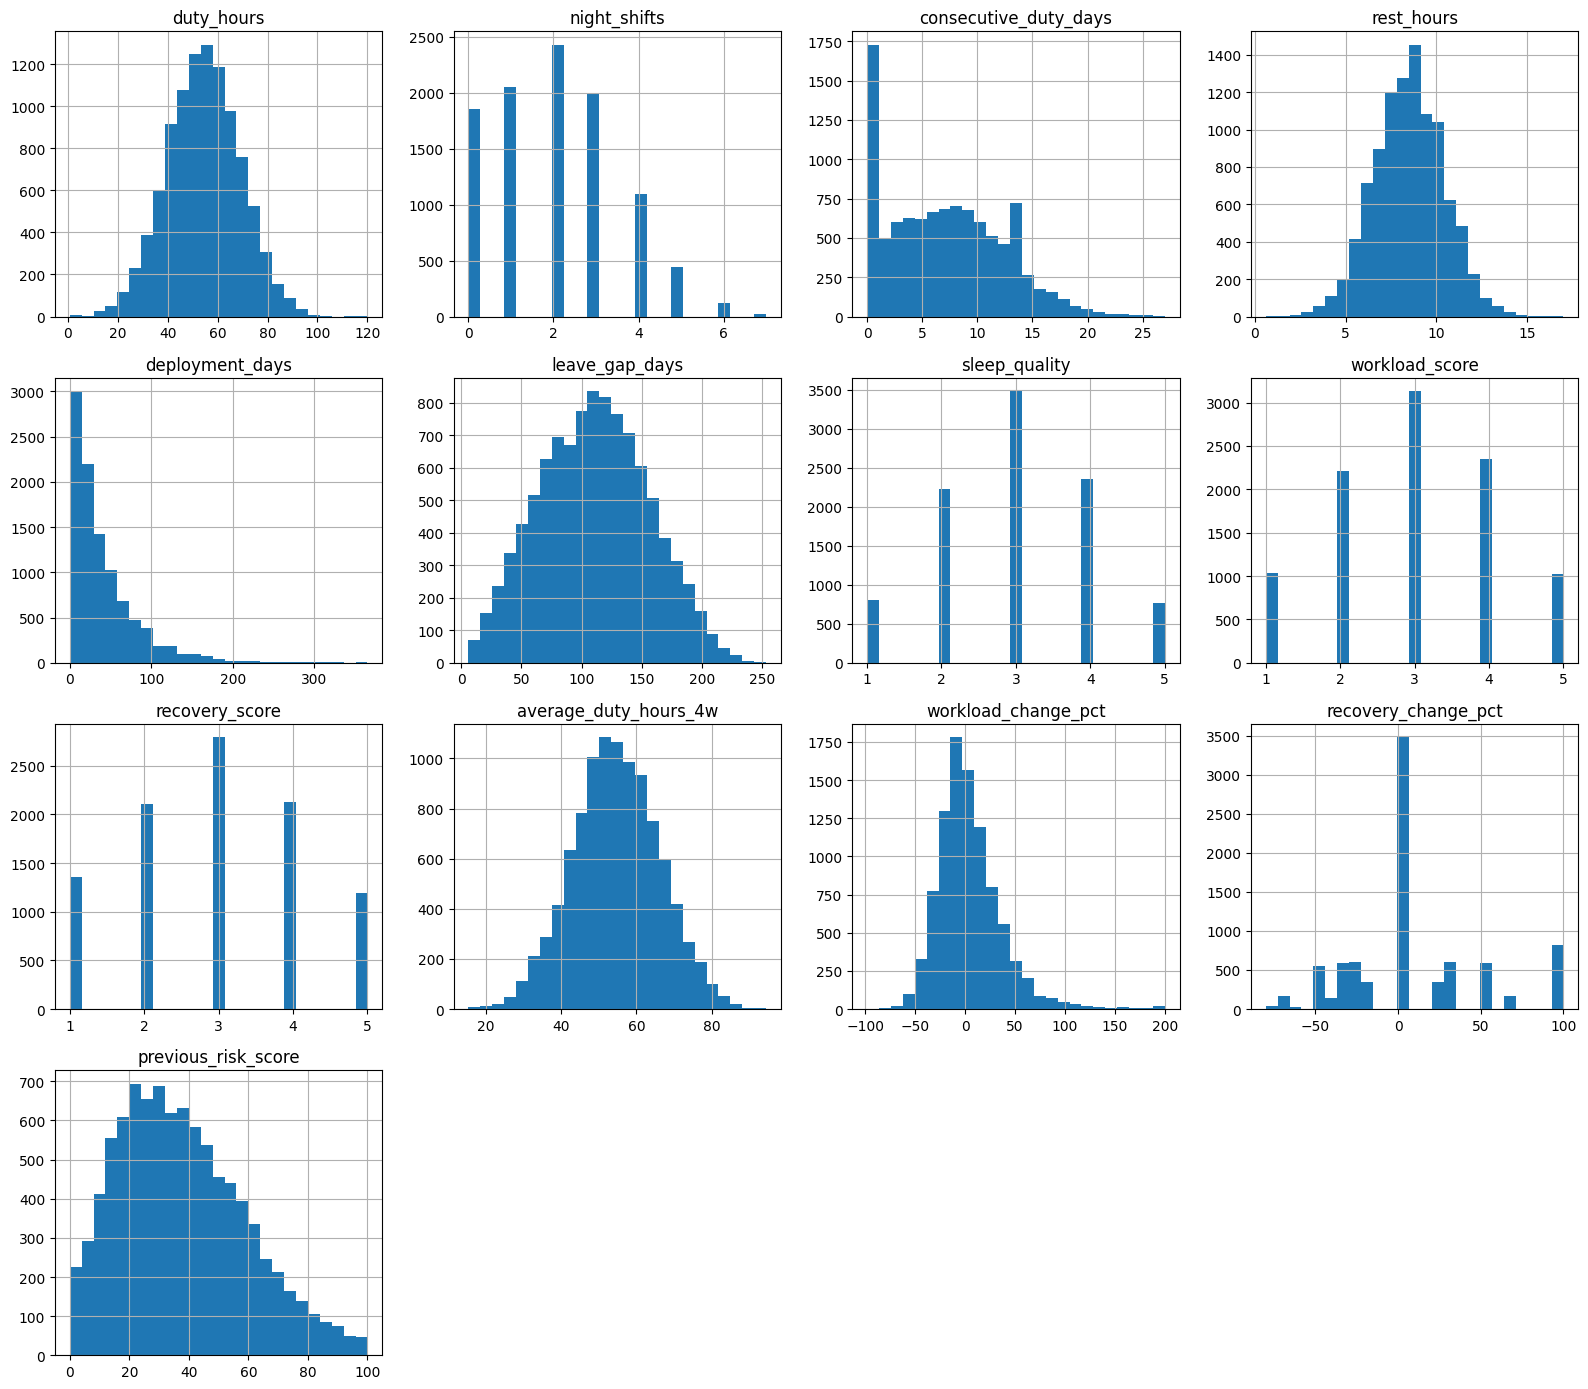

In [24]:
df[FEATURES].hist(
    figsize=(16, 14),
    bins=25
)

plt.tight_layout()
plt.show()

In [25]:
print(
    df["risk_score"].describe()
)

count   10000.00
mean       37.63
std        21.19
min         0.00
25%        21.30
50%        35.20
75%        51.73
max       100.00
Name: risk_score, dtype: float64


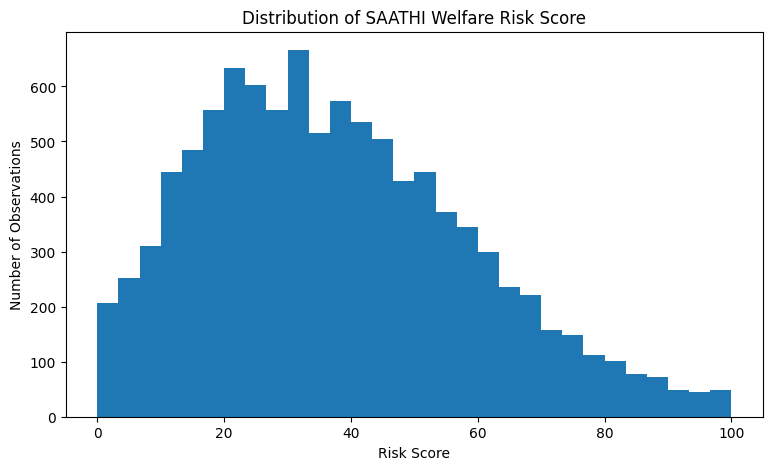

In [26]:
plt.figure(figsize=(9, 5))

plt.hist(
    df["risk_score"],
    bins=30
)

plt.xlabel("Risk Score")
plt.ylabel("Number of Observations")
plt.title("Distribution of SAATHI Welfare Risk Score")

plt.show()

In [27]:
risk_counts = df["risk_level"].value_counts()

print(risk_counts)

risk_level
Low         4070
Moderate    3218
Elevated    2133
High         579
Name: count, dtype: int64


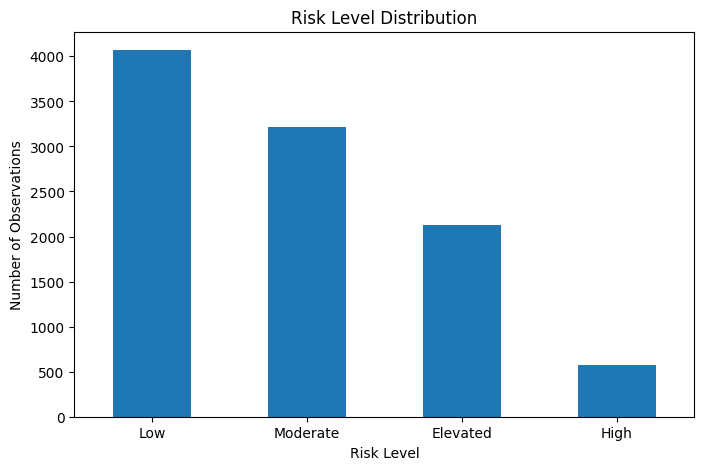

In [28]:
plt.figure(figsize=(8, 5))

risk_counts.plot(
    kind="bar"
)

plt.xlabel("Risk Level")
plt.ylabel("Number of Observations")
plt.title("Risk Level Distribution")

plt.xticks(rotation=0)

plt.show()

In [29]:
risk_percentage = (
    df["risk_level"]
    .value_counts(normalize=True)
    * 100
)

print(
    risk_percentage.round(2)
)

risk_level
Low        40.70
Moderate   32.18
Elevated   21.33
High        5.79
Name: proportion, dtype: float64


In [30]:
def expected_risk_level(score):

    if score <= 30:
        return "Low"
    elif score <= 50:
        return "Moderate"
    elif score <= 75:
        return "Elevated"
    else:
        return "High"


df["expected_risk_level"] = (
    df["risk_score"]
    .apply(expected_risk_level)
)

mismatches = (
    df["risk_level"] != df["expected_risk_level"]
).sum()

print(
    "Risk level mismatches:",
    mismatches
)

Risk level mismatches: 0


In [31]:
correlations = (
    df[FEATURES + [TARGET]]
    .corr()["risk_score"]
    .sort_values(
        ascending=False
    )
)

correlations

risk_score               1.00
previous_risk_score      0.93
average_duty_hours_4w    0.54
duty_hours               0.48
consecutive_duty_days    0.41
night_shifts             0.38
deployment_days          0.13
workload_change_pct     -0.01
recovery_change_pct     -0.02
leave_gap_days          -0.02
rest_hours              -0.42
sleep_quality           -0.48
workload_score          -0.52
recovery_score          -0.56
Name: risk_score, dtype: float64


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


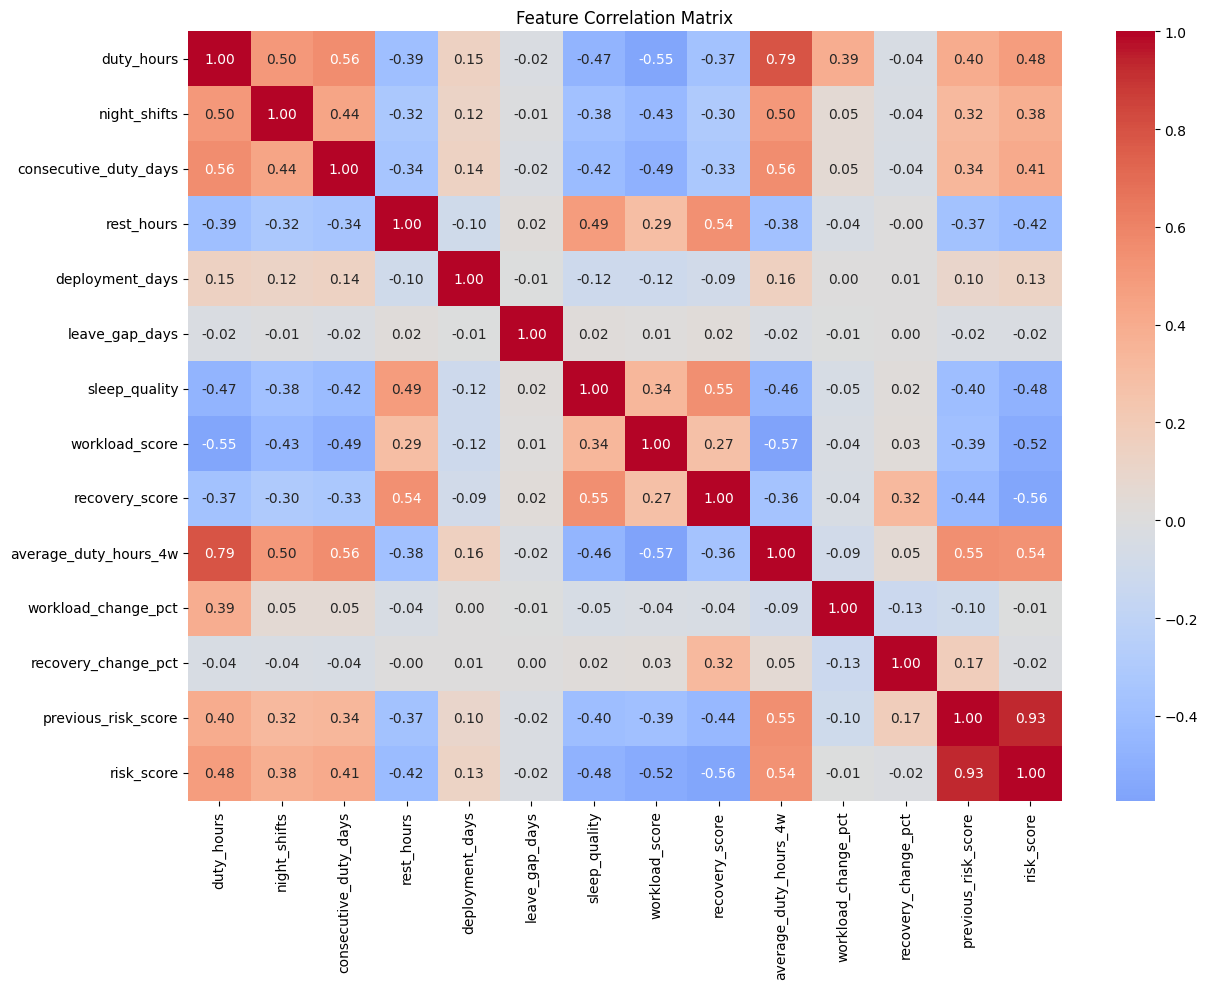

In [32]:
!pip3 install seaborn
import seaborn as sns
plt.figure(figsize=(13, 10))

correlation_matrix = (
    df[FEATURES + [TARGET]]
    .corr()
)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Feature Correlation Matrix"
)

plt.tight_layout()
plt.show()

In [33]:
df[
    ["previous_risk_score", "risk_score"]
].corr()

,previous_risk_score,risk_score
previous_risk_score,1.00,0.93
risk_score,0.93,1.00


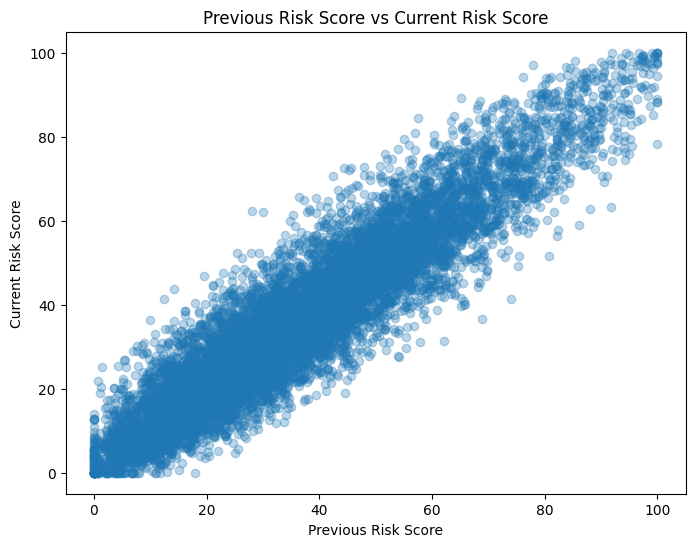

In [34]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["previous_risk_score"],
    df["risk_score"],
    alpha=0.3
)

plt.xlabel("Previous Risk Score")
plt.ylabel("Current Risk Score")

plt.title(
    "Previous Risk Score vs Current Risk Score"
)

plt.show()

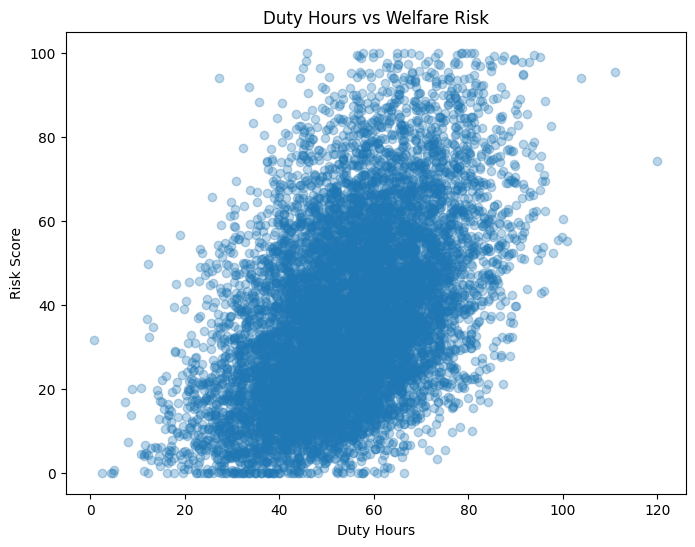

In [35]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["duty_hours"],
    df["risk_score"],
    alpha=0.3
)

plt.xlabel("Duty Hours")
plt.ylabel("Risk Score")

plt.title(
    "Duty Hours vs Welfare Risk"
)

plt.show()

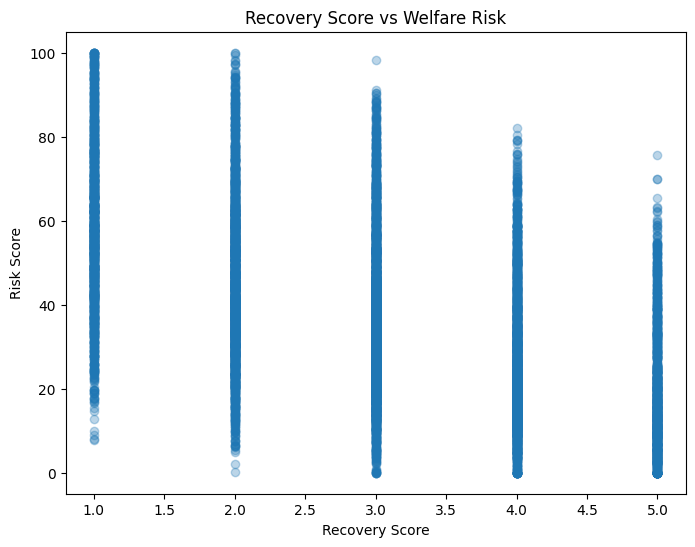

In [36]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["recovery_score"],
    df["risk_score"],
    alpha=0.3
)

plt.xlabel("Recovery Score")
plt.ylabel("Risk Score")

plt.title(
    "Recovery Score vs Welfare Risk"
)

plt.show()

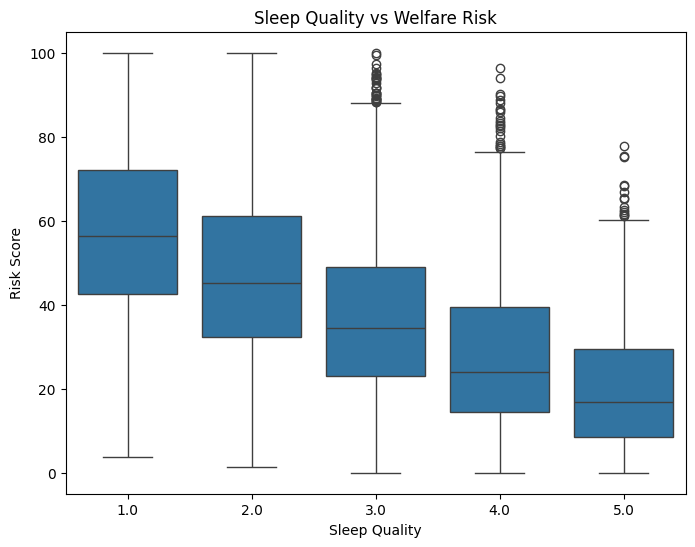

In [37]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="sleep_quality",
    y="risk_score"
)

plt.xlabel("Sleep Quality")
plt.ylabel("Risk Score")

plt.title(
    "Sleep Quality vs Welfare Risk"
)

plt.show()

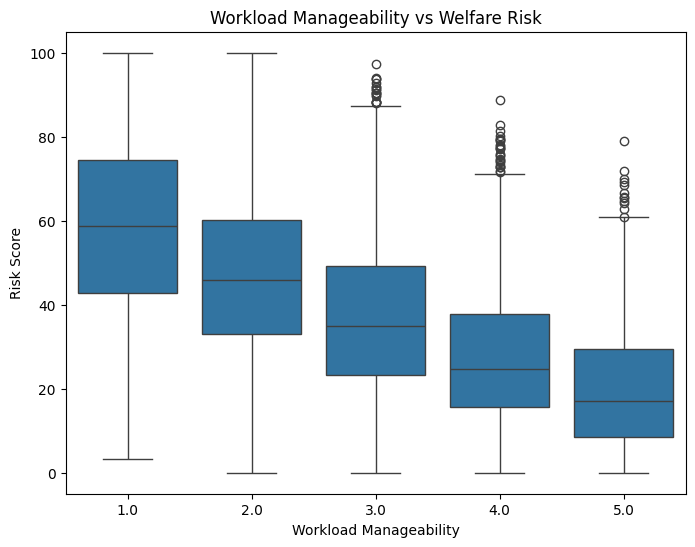

In [38]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="workload_score",
    y="risk_score"
)

plt.xlabel("Workload Manageability")
plt.ylabel("Risk Score")

plt.title(
    "Workload Manageability vs Welfare Risk"
)

plt.show()

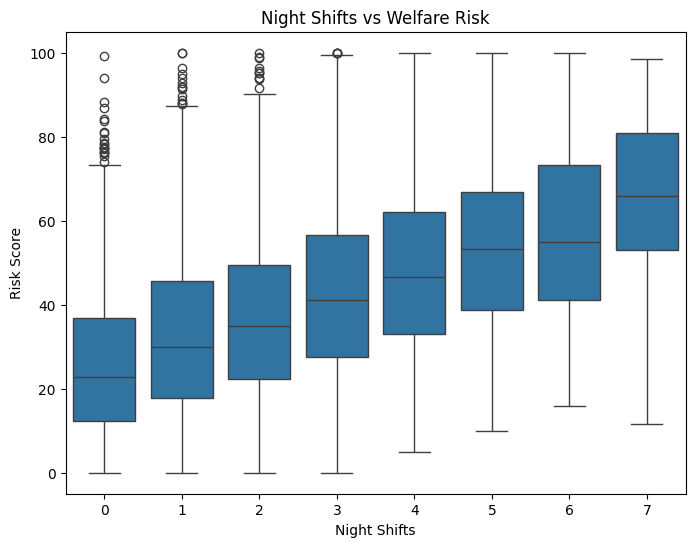

In [39]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="night_shifts",
    y="risk_score"
)

plt.xlabel("Night Shifts")
plt.ylabel("Risk Score")

plt.title(
    "Night Shifts vs Welfare Risk"
)

plt.show()

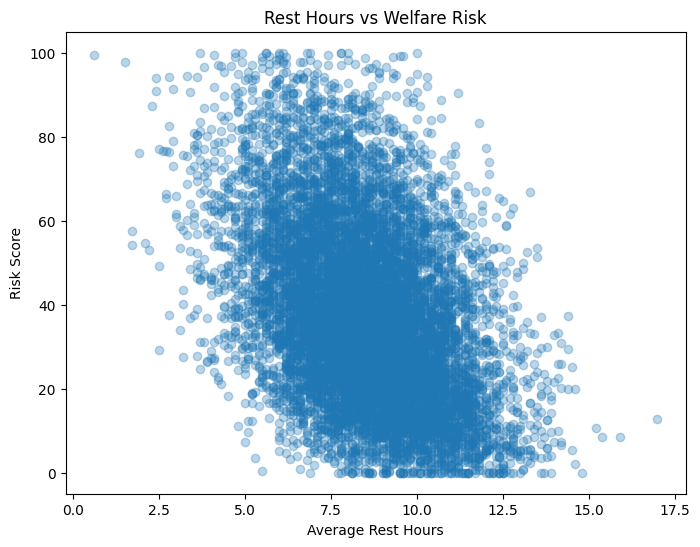

In [40]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["rest_hours"],
    df["risk_score"],
    alpha=0.3
)

plt.xlabel("Average Rest Hours")
plt.ylabel("Risk Score")

plt.title(
    "Rest Hours vs Welfare Risk"
)

plt.show()

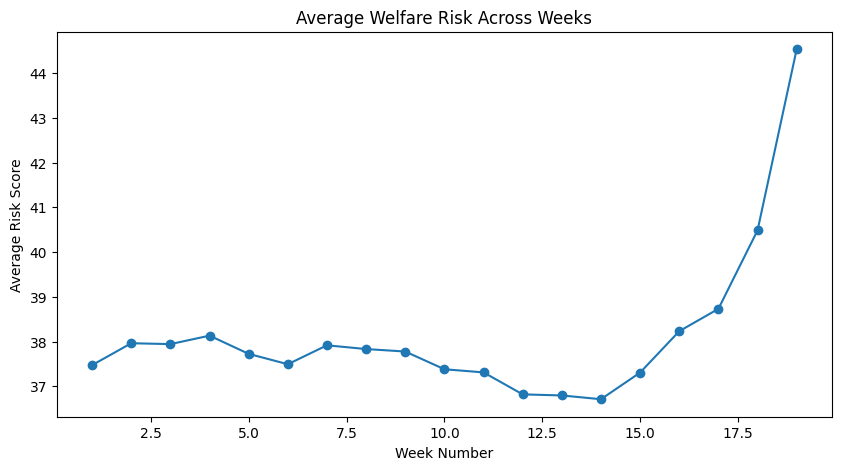

In [41]:
weekly_risk = (
    df.groupby("week_number")["risk_score"]
      .mean()
)

plt.figure(figsize=(10, 5))

plt.plot(
    weekly_risk.index,
    weekly_risk.values,
    marker="o"
)

plt.xlabel("Week Number")
plt.ylabel("Average Risk Score")

plt.title(
    "Average Welfare Risk Across Weeks"
)

plt.show()

In [42]:
example_person = df["personnel_id"].iloc[0]

person_history = (
    df[df["personnel_id"] == example_person]
    .sort_values("assessment_date")
)

person_history[
    [
        "assessment_date",
        "duty_hours",
        "sleep_quality",
        "recovery_score",
        "previous_risk_score",
        "risk_score",
        "risk_level"
    ]
]

,assessment_date,duty_hours,sleep_quality,recovery_score,previous_risk_score,risk_score,risk_level
0,2025-02-17,58.90,3.00,3.00,NaN,23.80,Low
1,2025-02-24,71.70,2.00,NaN,23.80,28.40,Low
2,2025-03-03,56.20,2.00,2.00,28.40,29.30,Low
3,2025-03-10,71.70,2.00,2.00,29.30,31.70,Moderate
4,2025-03-17,72.70,3.00,1.00,31.70,48.70,Moderate
5,2025-03-24,81.70,3.00,1.00,48.70,54.00,Elevated
6,2025-03-31,74.80,2.00,3.00,54.00,49.70,Moderate
7,2025-04-07,78.70,2.00,1.00,49.70,55.90,Elevated
8,2025-04-14,61.70,3.00,2.00,55.90,39.30,Moderate
9,2025-04-21,55.50,NaN,3.00,39.30,39.60,Moderate


## EDA Summary

The dataset was examined for:

- Dataset size and structure
- Personnel-level observations
- Missing values
- Duplicate records
- Feature ranges
- Risk-score distribution
- Risk-level distribution
- Feature correlations
- Potential data leakage
- Longitudinal behavior
- Relationships between operational/wellness variables and welfare risk

The dataset will proceed to model training only after confirming that
the distributions, ranges, missingness, temporal structure, and feature
relationships are reasonable.

In [43]:
missing_df

,Missing Count,Missing %
recovery_change_pct,1532,15.32
previous_risk_score,750,7.50
workload_change_pct,750,7.50
recovery_score,425,4.25
sleep_quality,360,3.60
workload_score,247,2.47
personnel_id,0,0.00
risk_score,0,0.00
average_duty_hours_4w,0,0.00
leave_gap_days,0,0.00


In [44]:
missing_cols = [
    "sleep_quality",
    "workload_score",
    "recovery_score",
    "workload_change_pct",
    "recovery_change_pct",
    "previous_risk_score"
]

df[missing_cols].isnull().sum()

sleep_quality           360
workload_score          247
recovery_score          425
workload_change_pct     750
recovery_change_pct    1532
previous_risk_score     750
dtype: int64

In [45]:
df[missing_cols].isnull().mean().mul(100).round(2)

sleep_quality          3.60
workload_score         2.47
recovery_score         4.25
workload_change_pct    7.50
recovery_change_pct   15.32
previous_risk_score    7.50
dtype: float64

In [46]:
first_observation = (
    df.groupby("personnel_id")["assessment_date"]
      .transform("min")
      == df["assessment_date"]
)

print(
    "First observations:",
    first_observation.sum()
)

print(
    "Missing previous_risk_score on first observations:",
    df.loc[
        first_observation,
        "previous_risk_score"
    ].isna().sum()
)

print(
    "Missing workload_change_pct on first observations:",
    df.loc[
        first_observation,
        "workload_change_pct"
    ].isna().sum()
)

print(
    "Missing recovery_change_pct on first observations:",
    df.loc[
        first_observation,
        "recovery_change_pct"
    ].isna().sum()
)

First observations: 750
Missing previous_risk_score on first observations: 750
Missing workload_change_pct on first observations: 750
Missing recovery_change_pct on first observations: 750


In [47]:
df[
    df["recovery_change_pct"].isna()
][
    [
        "personnel_id",
        "assessment_date",
        "week_number",
        "recovery_score",
        "recovery_change_pct"
    ]
].head(20)

,personnel_id,assessment_date,week_number,recovery_score,recovery_change_pct
0,P1000,2025-02-17,1,3.00,NaN
1,P1000,2025-02-24,2,NaN,NaN
2,P1000,2025-03-03,3,2.00,NaN
15,P1001,2025-01-06,1,2.00,NaN
27,P1001,2025-03-31,13,NaN,NaN
28,P1001,2025-04-07,14,2.00,NaN
29,P1002,2025-02-24,1,4.00,NaN
45,P1002,2025-06-16,17,NaN,NaN
46,P1003,2025-02-24,1,3.00,NaN
57,P1004,2025-02-17,1,4.00,NaN


In [48]:
df["risk_score"].describe()

count   10000.00
mean       37.63
std        21.19
min         0.00
25%        21.30
50%        35.20
75%        51.73
max       100.00
Name: risk_score, dtype: float64

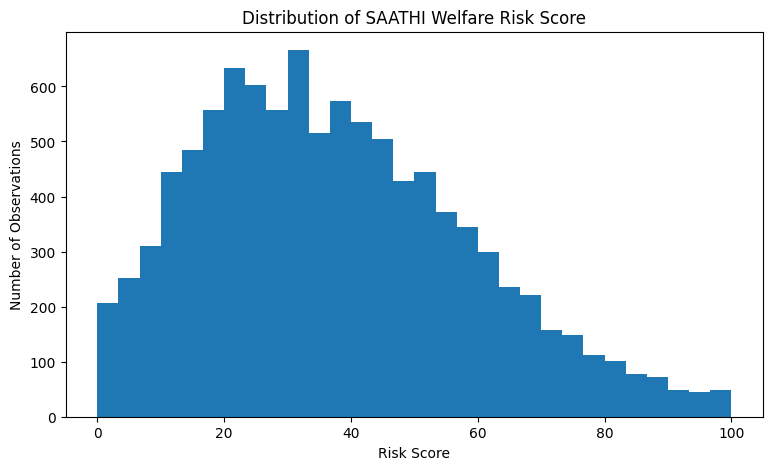

In [49]:
plt.figure(figsize=(9, 5))

plt.hist(
    df["risk_score"],
    bins=30
)

plt.xlabel("Risk Score")
plt.ylabel("Number of Observations")
plt.title("Distribution of SAATHI Welfare Risk Score")

plt.show()

In [50]:
df["risk_level"].value_counts()

risk_level
Low         4070
Moderate    3218
Elevated    2133
High         579
Name: count, dtype: int64

In [51]:
df["risk_level"].value_counts(normalize=True).mul(100).round(2)

risk_level
Low        40.70
Moderate   32.18
Elevated   21.33
High        5.79
Name: proportion, dtype: float64

In [52]:
def expected_risk_level(score):

    if score <= 30:
        return "Low"
    elif score <= 50:
        return "Moderate"
    elif score <= 75:
        return "Elevated"
    else:
        return "High"


expected = df["risk_score"].apply(
    expected_risk_level
)

print(
    "Risk level mismatches:",
    (expected != df["risk_level"]).sum()
)

Risk level mismatches: 0


In [53]:
print("Risk Score Statistics:")
print(df["risk_score"].describe())

print("\nRisk Score Range:")
print("Min:", df["risk_score"].min())
print("Max:", df["risk_score"].max())

Risk Score Statistics:
count   10000.00
mean       37.63
std        21.19
min         0.00
25%        21.30
50%        35.20
75%        51.73
max       100.00
Name: risk_score, dtype: float64

Risk Score Range:
Min: 0.0
Max: 100.0


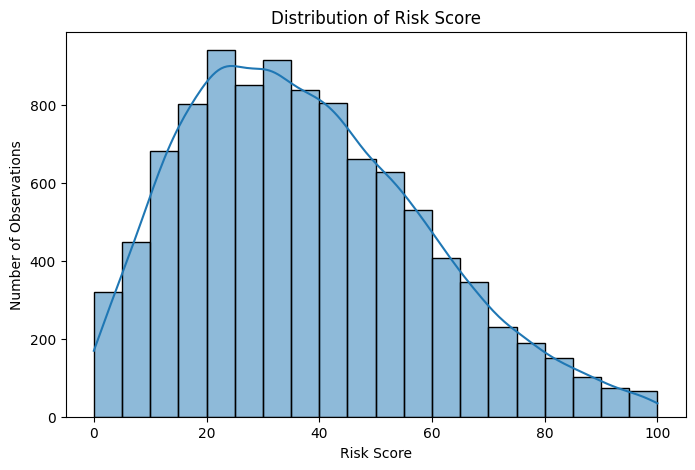

In [54]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["risk_score"],
    bins=20,
    kde=True
)

plt.title("Distribution of Risk Score")
plt.xlabel("Risk Score")
plt.ylabel("Number of Observations")
plt.show()

In [55]:
risk_counts = df["risk_level"].value_counts()

print(risk_counts)

print("\nPercentages:")
print(
    (df["risk_level"].value_counts(normalize=True) * 100)
    .round(2)
)

risk_level
Low         4070
Moderate    3218
Elevated    2133
High         579
Name: count, dtype: int64

Percentages:
risk_level
Low        40.70
Moderate   32.18
Elevated   21.33
High        5.79
Name: proportion, dtype: float64


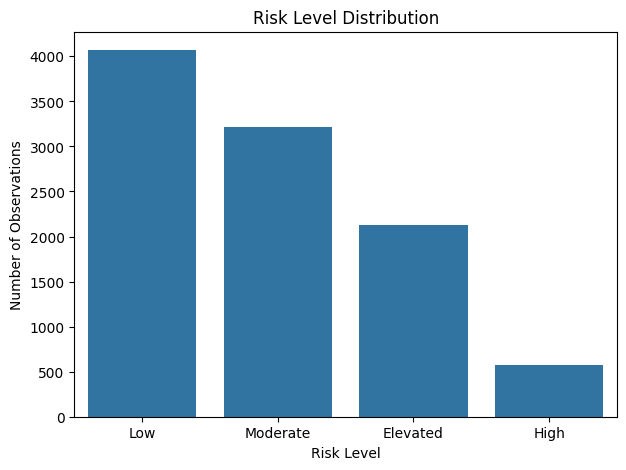

In [56]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="risk_level",
    order=["Low", "Moderate", "Elevated", "High"]
)

plt.title("Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Observations")
plt.show()

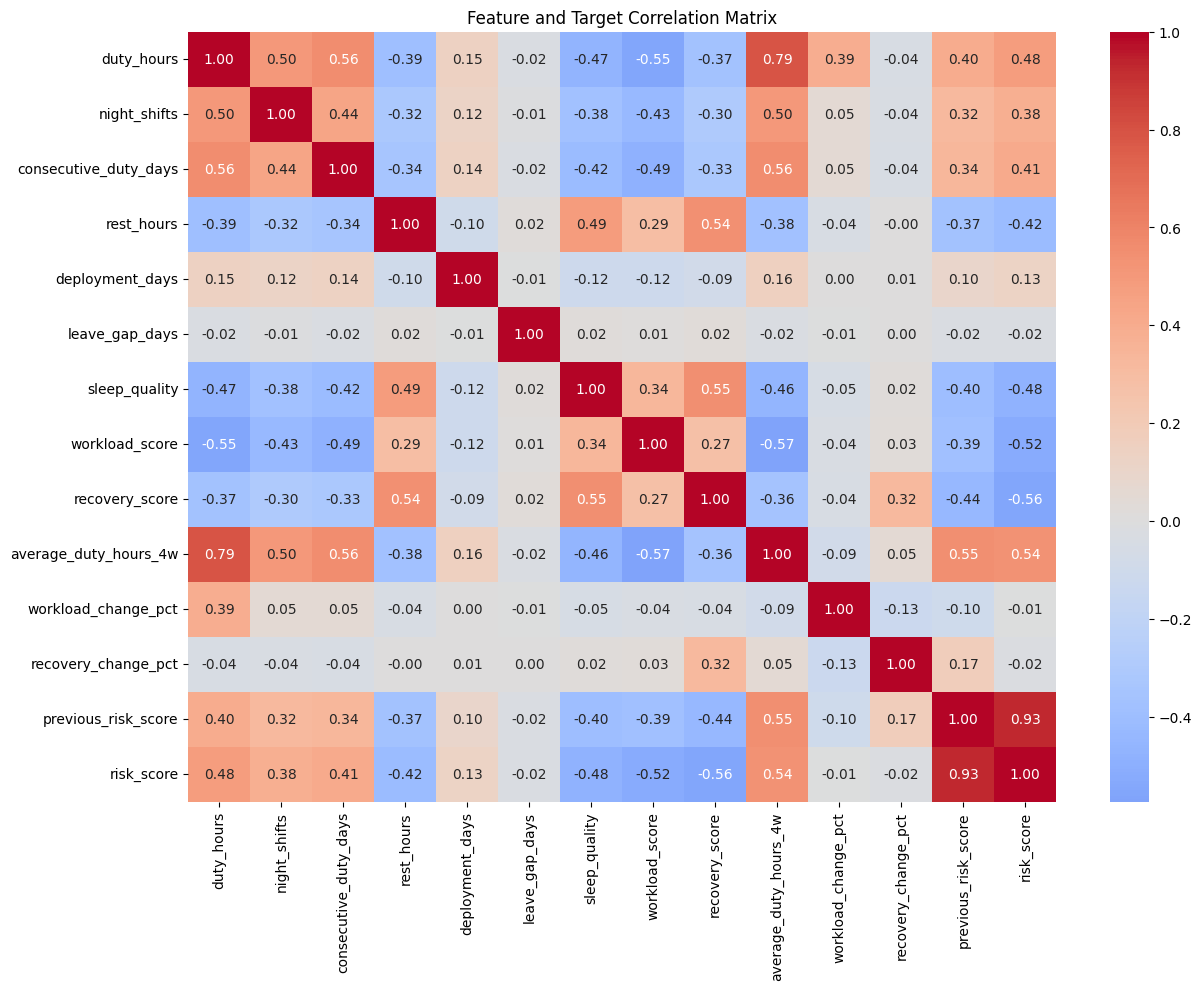

In [57]:
corr_cols = [
    "duty_hours",
    "night_shifts",
    "consecutive_duty_days",
    "rest_hours",
    "deployment_days",
    "leave_gap_days",
    "sleep_quality",
    "workload_score",
    "recovery_score",
    "average_duty_hours_4w",
    "workload_change_pct",
    "recovery_change_pct",
    "previous_risk_score",
    "risk_score"
]

corr = df[corr_cols].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Feature and Target Correlation Matrix")
plt.show()